In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR          
from torch.amp import autocast, GradScaler
from torchinfo import summary
from torch.amp import autocast, GradScaler
import random
import os
import glob
from PIL import Image
from sklearn.metrics import f1_score
import numpy as np
import warnings
import seaborn as sns
from collections import Counter

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
train_dataset_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomApply(
    [transforms.RandomRotation(45)],
    p=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.90, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_dataset_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_dataset_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

full_train_dataset = datasets.ImageFolder(root=R"/kaggle/input/detect-trash-type/train")

train_dataset_size = int(0.8 * len(full_train_dataset))
val_dataset_size = len(full_train_dataset) - train_dataset_size

torch.manual_seed(42)
train_dataset_indices, val_dataset_indices = random_split(
    range(len(full_train_dataset)), [train_dataset_size, val_dataset_size]
)

train_dataset = Subset(datasets.ImageFolder(root=R"/kaggle/input/detect-trash-type/train",
                                            transform=train_dataset_transform), train_dataset_indices)
val_dataset = Subset(datasets.ImageFolder(root=R"/kaggle/input/detect-trash-type/train",
                                          transform=val_dataset_transform), val_dataset_indices)

train_dataset_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    num_workers=4,
    shuffle=True,
    pin_memory=True,
    persistent_workers = True
)

val_dataset_loader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    num_workers=4,
    shuffle=False,
    pin_memory=True,
    persistent_workers = True
)

test_folder = "/kaggle/input/detect-trash-type/test"
test_images_files_paths = sorted(glob.glob(os.path.join(test_folder, "img_*.jpg")) +
                         glob.glob(os.path.join(test_folder, "img_*.png")))

In [3]:
all_labels = [label for _, label in train_dataset]
classes_counter = Counter(all_labels)

classes_counter = dict(sorted(classes_counter.items()))
print(classes_counter)

{0: 603, 1: 659, 2: 1138, 3: 3419, 4: 2123, 5: 653, 6: 1224, 7: 1266, 8: 1462, 9: 589}


In [4]:
n_classes = len(full_train_dataset.classes)
total_samples = len(train_dataset)

classes_weights = torch.zeros(n_classes, dtype=torch.float)

for cls, count in classes_counter.items():
    classes_weights[cls] = total_samples / (n_classes * count)

print("Class weights:", classes_weights)

Class weights: tensor([2.1784, 1.9933, 1.1543, 0.3842, 0.6187, 2.0116, 1.0732, 1.0376, 0.8985,
        2.2302])


In [5]:
from torchvision.models import EfficientNet_B4_Weights

In [6]:
weights = EfficientNet_B4_Weights.DEFAULT
efficientnet_b4 = models.efficientnet_b4(weights=weights)

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 243MB/s]


In [7]:
def generate_efficientnet_b4_classifier_layers(num_classes):
    fully_connected_layers = nn.Sequential(
        nn.Linear(1792, 256), 
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.3),
    
        nn.Linear(256, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.3),
    
        nn.Linear(128, num_classes)
    )

    return fully_connected_layers

classifier_layers = generate_efficientnet_b4_classifier_layers(len(full_train_dataset.classes))

In [8]:
efficientnet_b4.classifier = classifier_layers

In [9]:
print(summary(efficientnet_b4, input_size=(1, 3, 384, 384)))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 10]                   --
├─Sequential: 1-1                                       [1, 1792, 12, 12]         --
│    └─Conv2dNormActivation: 2-1                        [1, 48, 192, 192]         --
│    │    └─Conv2d: 3-1                                 [1, 48, 192, 192]         1,296
│    │    └─BatchNorm2d: 3-2                            [1, 48, 192, 192]         96
│    │    └─SiLU: 3-3                                   [1, 48, 192, 192]         --
│    └─Sequential: 2-2                                  [1, 24, 192, 192]         --
│    │    └─MBConv: 3-4                                 [1, 24, 192, 192]         2,940
│    │    └─MBConv: 3-5                                 [1, 24, 192, 192]         1,206
│    └─Sequential: 2-3                                  [1, 32, 96, 96]           --
│    │    └─MBConv: 3-6                            

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = efficientnet_b4.to(device=device)
classes_weights = classes_weights.to(device=device)
criterion = nn.CrossEntropyLoss(weight=classes_weights)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.02)
scheduler = CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-5)

In [11]:
def eval_model(model, dataset_loader):
    model.eval()

    true_predicted_counter = 0
    total_predicted_counter = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for data_inputs, data_labels in dataset_loader:
            data_inputs = data_inputs.to('cuda')
            data_labels = data_labels.to('cuda')

            model_prediction = model(data_inputs)
            prediction_labels = model_prediction.argmax(dim=1)

            true_predicted_counter += (prediction_labels == data_labels).sum().item()
            total_predicted_counter += data_labels.size(0)

            all_predictions.extend(prediction_labels.cpu().numpy())
            all_labels.extend(data_labels.cpu().numpy())

    acc = true_predicted_counter / total_predicted_counter
    f1 = f1_score(all_labels, all_predictions, average='macro')  

    return (acc * 100), f1

In [12]:
scaler = GradScaler()                                          

os.makedirs("/kaggle/working/outputs", exist_ok=True)          

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=20, patience=5):
    best_f1_macro = 0.0     
    no_improvement = 0      
    train_accuracy_per_epoch = []
    val_accuracy_per_epoch = []
    val_f1_macro_score_per_epoch = []

    for epoch in range(1, epochs + 1):
        model.train()                                    
        TP_predictions_couter = 0
        total_predictions_counter = 0
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to('cuda')
            labels = labels.to('cuda')

            optimizer.zero_grad()                        

            with autocast(device_type='cuda'):  
                model_prediction_probabilities = model(images)
                loss = criterion(model_prediction_probabilities, labels)

            scaler.scale(loss).backward()                
            scaler.unscale_(optimizer)                   
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  
            scaler.step(optimizer)                       
            scaler.update()                              

            running_loss += loss.item()
            final_prediction = model_prediction_probabilities.argmax(dim=1)
            TP_predictions_couter += (final_prediction == labels).sum().item()
            total_predictions_counter += labels.size(0)

        train_acc = 100 * TP_predictions_couter / total_predictions_counter
        train_accuracy_per_epoch.append(train_acc)

        val_acc, val_macro_f1= eval_model(model, val_loader)
        val_accuracy_per_epoch.append(val_acc)
        val_f1_macro_score_per_epoch.append(val_macro_f1)

        scheduler.step()                                 

        print(f"Epoch {epoch:3d} | Train: {train_acc:6.2f}% | Val: {val_acc:6.2f}% | "
              f"Loss: {running_loss/len(train_loader):.4f} | Val macro f1: {val_macro_f1:.4f}")

        if val_macro_f1 > best_f1_macro:
            best_f1_macro = val_macro_f1
            torch.save(model, "/kaggle/working/outputs/best_model.pth")
            no_improvement = 0
        else:
            no_improvement += 1

        if no_improvement >= patience:
            break

    print("Training finished!")
    return train_accuracy_per_epoch, val_accuracy_per_epoch, val_f1_macro_score_per_epoch

In [13]:
epochs = 25
train_acc_trajectory, validation_acc_trajectory, val_f1_macro_trajectory=train_model(model,train_dataset_loader,
val_dataset_loader,criterion, optimizer, epochs=epochs, patience=6)

Epoch   1 | Train:  87.09% | Val:  95.10% | Loss: 0.5018 | Val macro f1: 0.9373
Epoch   2 | Train:  92.85% | Val:  96.07% | Loss: 0.2737 | Val macro f1: 0.9502
Epoch   3 | Train:  94.78% | Val:  96.80% | Loss: 0.2022 | Val macro f1: 0.9598
Epoch   4 | Train:  95.64% | Val:  96.89% | Loss: 0.1454 | Val macro f1: 0.9616
Epoch   5 | Train:  96.41% | Val:  96.53% | Loss: 0.1360 | Val macro f1: 0.9556
Epoch   6 | Train:  96.73% | Val:  95.74% | Loss: 0.1133 | Val macro f1: 0.9500
Epoch   7 | Train:  97.56% | Val:  97.14% | Loss: 0.0888 | Val macro f1: 0.9633
Epoch   8 | Train:  97.87% | Val:  96.93% | Loss: 0.0774 | Val macro f1: 0.9641
Epoch   9 | Train:  98.04% | Val:  97.44% | Loss: 0.0655 | Val macro f1: 0.9687
Epoch  10 | Train:  98.16% | Val:  97.63% | Loss: 0.0671 | Val macro f1: 0.9710
Epoch  11 | Train:  98.56% | Val:  97.60% | Loss: 0.0518 | Val macro f1: 0.9700
Epoch  12 | Train:  99.14% | Val:  97.87% | Loss: 0.0353 | Val macro f1: 0.9736
Epoch  13 | Train:  99.05% | Val:  97.66

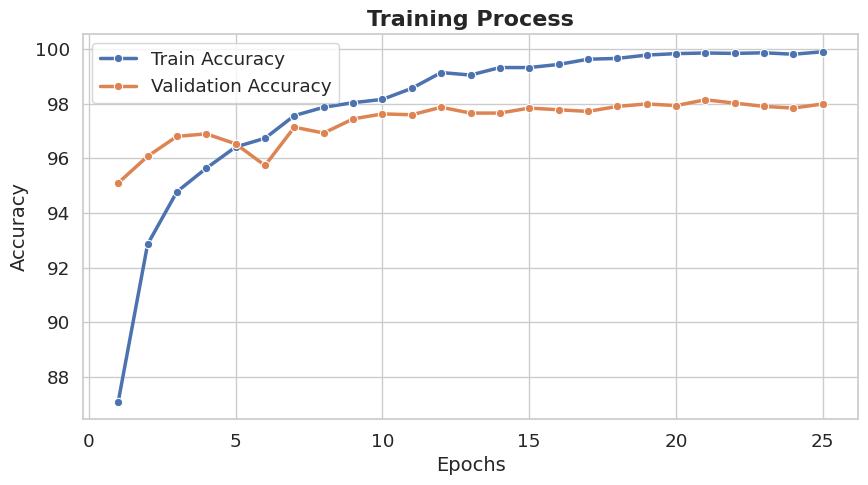

In [14]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid",palette="deep",font_scale=1.2)
sns.lineplot(x=range(1, epochs+1), y=train_acc_trajectory, label='Train Accuracy', marker='o', linewidth=2.5)
sns.lineplot(x=range(1, epochs+1), y=validation_acc_trajectory, label='Validation Accuracy', marker='o', 
            linewidth=2.5)
plt.ylabel('Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=14)
plt.title('Training Process', fontsize=16, weight="bold")
plt.legend()
plt.show()

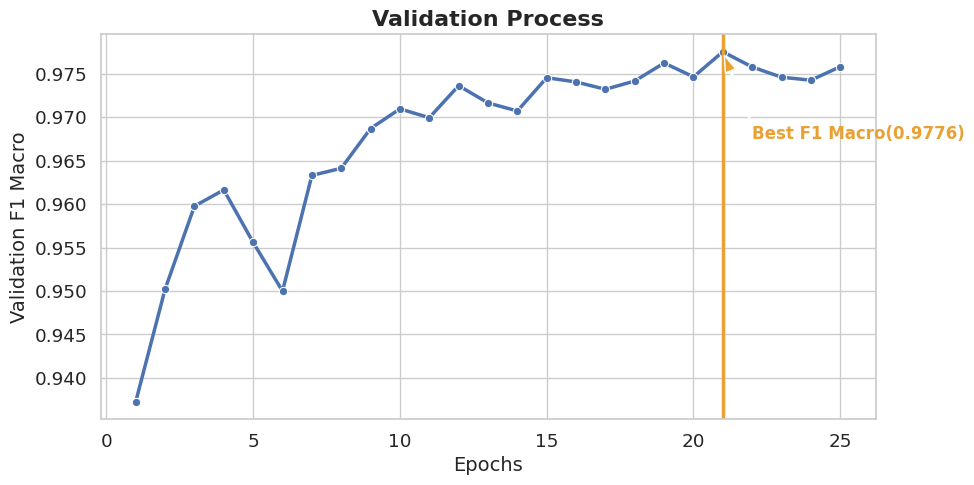

In [15]:
best_epoch_index = np.argmax(val_f1_macro_trajectory) 
best_f1 = val_f1_macro_trajectory[best_epoch_index]

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid",palette="deep",font_scale=1.2)
sns.lineplot(x=range(1, epochs+1), y=val_f1_macro_trajectory, marker='o', linewidth=2.5)
plt.axvline(x=best_epoch_index+1, color='#E9A134', linestyle='-', linewidth=2.5)
plt.annotate(f'Best F1 Macro({best_f1:0.4f})', 
             xy=(best_epoch_index+1, best_f1),               
             xytext=(best_epoch_index + 2, best_f1 - 0.01), 
             arrowprops=dict(facecolor='#E9A134', shrink=0.05, width=1, headwidth=8),
             fontsize=12, color='#E9A134', fontweight='bold')
plt.ylabel('Validation F1 Macro', fontsize=14)
plt.xlabel('Epochs', fontsize=14)
plt.title('Validation Process', fontsize=16, weight="bold")
plt.show()

In [16]:
def predict_test_images(model, image_paths, transform, class_names):
    model.eval()
    predictions = []

    with torch.no_grad():
        for idx, image_path in enumerate(image_paths):
            image = Image.open(image_path).convert('RGB')
            image_tensor = transform(image).unsqueeze(0).to(device)

            output = model(image_tensor)
            _, predicted_idx = torch.max(output, 1)
            predicted_class = class_names[predicted_idx.item()]

            image_id = os.path.basename(image_path)
            predictions.append((image_id, predicted_class))

    return predictions

classes = full_train_dataset.classes
predictions = predict_test_images(model, test_images_files_paths, test_dataset_transform, classes)

In [17]:
submission_df = pd.DataFrame(predictions, columns=['ID', 'Label'])
submission_filename = 'submission_file.csv'
submission_df.to_csv(submission_filename, index=False)